# Decision Tree Construction from Scratch Using Gini Impurity

### Categorical Splits, Numerical Thresholds, and Recursive Tree Building

This notebook develops the building blocks of a **classification decision tree from scratch** using Gini impurity. It covers categorical impurity, threshold selection for numerical variables, weighted impurity, and recursive split construction on a small illustrative loan-approval dataset.

**Project context:** This was originally completed as a collaborative academic exercise. Personal and course-identifying information has been removed for the portfolio version.

In [1]:
import pandas as pd
import numpy as np

## 1. Gini Impurity for a Binary Target

For class proportions \(p_1,\ldots,p_K\), Gini impurity is

\[
G = 1-\sum_{k=1}^{K}p_k^2.
\]

For a binary Yes/No target, impurity is lowest when a node contains only one class and highest when the two classes are evenly mixed.

In [2]:
def ginic(nyes, nno):
    total = nyes + nno
    if total == 0:
        return 0 
    p_yes = nyes / total
    p_no = nno / total
    gini = 1 - (p_yes ** 2 + p_no ** 2)
    return gini

## 2. Numerical Split Selection

For a numerical predictor, candidate thresholds are generated between adjacent sorted values. Each threshold divides the observations into left and right nodes, whose weighted Gini impurity is then compared.

The function returns the threshold with the lowest weighted impurity.

In [3]:
def ginin(datanum, response):
    # Step 1: Sort the data with the corresponding response
    sorted_data = sorted(zip(datanum, response), key=lambda x: x[0])
    datanum = [x[0] for x in sorted_data]
    response = [x[1] for x in sorted_data]

    # Step 2: Generate all possible split midpoints
    thresholds = [(datanum[i] + datanum[i + 1]) / 2 for i in range(len(datanum) - 1)]

    best_split = [float('inf'), None]  # [lowest_gini, best_threshold]

    # Step 3: Try each split
    for threshold in thresholds:
        # Step 4: Split responses based on threshold
        left = [response[i] for i in range(len(datanum)) if datanum[i] <= threshold]
        right = [response[i] for i in range(len(datanum)) if datanum[i] > threshold]

        # Step 5: Count Yes/No
        left_yes = left.count("Yes")
        left_no = left.count("No")
        right_yes = right.count("Yes")
        right_no = right.count("No")

        # Step 6: Compute Gini for each group
        gini_left = giniC(left_yes, left_no)
        gini_right = giniC(right_yes, right_no)

        # Step 7: Compute weighted Gini
        weighted = w_gini(gini_left, gini_right, len(left), len(right))

        # Step 8: Track lowest Gini
        if weighted < best_split[0]:
            best_split = [weighted, threshold]

    return best_split  # [lowest_gini, best_split_threshold]

## 3. Weighted Gini Impurity

When evaluating a split, child-node impurities are weighted by their relative sample sizes:

\[
G_{\text{split}}
=
\frac{n_L}{n}G_L+
\frac{n_R}{n}G_R.
\]

In [4]:
def w_gini(gini_left, gini_right, nleft, nright):
    total = nleft + nright
    if total == 0:
        return 0  # Avoid division by zero
    weighted = (nleft / total) * gini_left + (nright / total) * gini_right
    return weighted

## 4. Decision-Tree Process Diagram

The original submission referenced an external image file named `lab7image.png`. That asset is not embedded in the archived notebook, so the display cell below is preserved exactly as originally run but the source image is not part of this portfolio package.

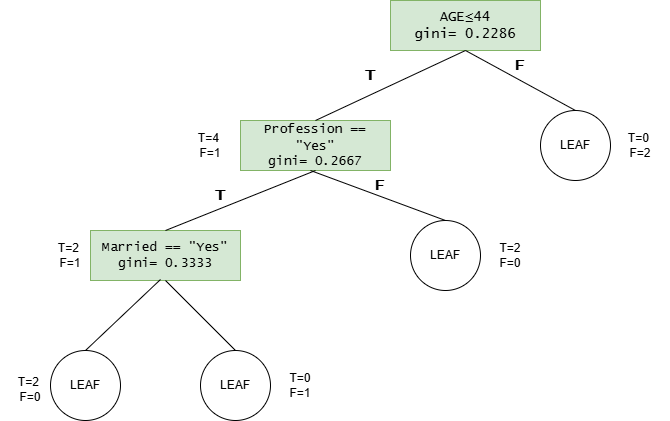

In [5]:
from IPython.display import Image
Image(filename='lab7image.png')

## 5. Illustrative Dataset

The example contains three predictors:

- `Profession` — categorical
- `Married` — categorical
- `Age` — numerical

The binary target is `Loan`.

In [6]:
data = pd.DataFrame({
    "Profession": ["Yes", "Yes", "No", "No", "Yes", "Yes", "No"],
    "Married":    ["Yes", "No",  "Yes", "Yes", "Yes", "No", "No"],
    "Age":        [20, 25, 29, 35, 38, 50, 83],
    "Loan":       ["No", "Yes", "Yes", "Yes", "Yes", "No", "No"]
})

## 6. Split-Evaluation Helpers

The following helpers:

- count target classes;
- compute Gini impurity;
- evaluate categorical one-vs-rest splits;
- evaluate numerical thresholds;
- partition the data according to a selected condition; and
- identify pure nodes or majority labels.

In [7]:
def count_loan(df):
    """Count the number of 'Yes' and 'No' in the Loan column."""
    nyes = (df["Loan"] == "Yes").sum()
    nno = (df["Loan"] == "No").sum()
    return nyes, nno

def giniC(yes, no):
    total = yes + no
    if total == 0:
        return 0
    p_yes = yes / total
    p_no = no / total
    return 1 - (p_yes ** 2 + p_no ** 2)

def w_gini(g1, g2, len1, len2):
    total = len1 + len2
    return (len1 / total) * g1 + (len2 / total) * g2

def ginin2(datanum, response):
    best_gini = float('inf')
    best_threshold = None
    for i in range(1, len(datanum)):
        left = response[:i]
        right = response[i:]
        left_yes, left_no = count_loan(pd.DataFrame({"Loan": left}))
        right_yes, right_no = count_loan(pd.DataFrame({"Loan": right}))
        g1 = giniC(left_yes, left_no)
        g2 = giniC(right_yes, right_no)
        wg = w_gini(g1, g2, len(left), len(right))
        if wg < best_gini:
            best_gini = wg
            best_threshold = (datanum[i-1] + datanum[i]) / 2  # dito ashlyyy
    return [best_gini, best_threshold]

In [8]:
def try_categorical_split(df, feature):
    best = {"condition": None, "wg": 1}
    for val in df[feature].unique():
        left = df[df[feature] == val]
        right = df[df[feature] != val]
        y1, n1 = count_loan(left)
        y2, n2 = count_loan(right)
        g1 = giniC(y1, n1)
        g2 = giniC(y2, n2)
        wg = w_gini(g1, g2, len(left), len(right))
        if wg < best["wg"]:
            best["condition"] = f"{feature} == {val}"
            best["wg"] = wg
    return best

def try_numerical_split(df, feature):
    datanum = sorted(df[feature].tolist())
    response = [x for _, x in sorted(zip(df[feature].tolist(), df["Loan"].tolist()))]
    best = ginin2(datanum, response)
    condition = f"{feature} <= {best[1]}"
    return {"condition": condition, "wg": best[0]}

def split_data(df, feature, condition):
    if "==" in condition:
        feature_value = condition.split("==")[1].strip()
        left = df[df[feature] == feature_value]
        right = df[df[feature] != feature_value]
    elif "<=" in condition:
        threshold = float(condition.split("<=")[1].strip())
        left = df[df[feature] <= threshold]
        right = df[df[feature] > threshold]
    else:
        raise ValueError(f"Unknown split condition: {condition}")
    return left, right

def is_pure(df):
    """Check if the node is pure (all rows have the same 'Loan' value)."""
    return len(df["Loan"].unique()) == 1

def majority_label(df):
    """Return the majority label for the 'Loan' column."""
    return df["Loan"].mode()[0]

## 7. Recursive Tree Construction

The recursive procedure evaluates all remaining features at a node, chooses the split with the lowest weighted Gini impurity, removes that feature from the candidate list, and continues until a pure node or feature exhaustion is reached.

The first definition is retained from the original notebook, followed by the lightweight `Node` representation and the final executable version used for the stored output.

In [9]:
# Recursive Decision Tree Construction
def decision_tree_array(df, features, level=0):
    # Base case: pure node (all 'Loan' values are the same).
    if is_pure(df):
        label = df["Loan"].iloc[0]
        output_array.append([f"Level {level}", "Leaf", label])
        return Node(label=label)
    
    # Base case: no features left.
    if not features:
        majority = majority_label(df)
        output_array.append([f"Level {level}", "Leaf", majority])
        return Node(label=majority)
    
    best_feature = None
    best_condition = None
    best_wg = 1
    
    # Evaluate each feature.
    for feature in features:
        if df[feature].dtype == 'O':  # Categorical feature
            result = try_categorical_split(df, feature)
        else:  # Numerical feature
            result = try_numerical_split(df, feature)
        if result["wg"] < best_wg:
            best_wg = result["wg"]
            best_feature = feature
            best_condition = result["condition"]
    
    # Record this split decision.
    output_array.append([f"Level {level}", best_feature, best_condition, best_wg])
    
    # Remove the chosen feature from future splits (if desired).
    remaining_features = features.copy()
    if best_feature in remaining_features:
        remaining_features.remove(best_feature)
    
    # Split the data.
    left_data, right_data = split_data(df, best_feature, best_condition)
    
    # Recurse on each branch.
    left_node = decision_tree_array(left_data, remaining_features, level + 1)
    right_node = decision_tree_array(right_data, remaining_features, level + 1)
    
    return Node(feature=best_feature, condition=best_condition, left=left_node, right=right_node)

In [10]:
class Node:
    def __init__(self, feature=None, condition=None, left=None, right=None, label=None):
        self.feature = feature
        self.condition = condition
        self.left = left
        self.right = right
        self.label = label
        
    def __repr__(self):
        if self.label is not None:
            return f"Leaf(label={self.label})"
        return f"Node(feature={self.feature}, condition={self.condition})"

In [11]:
output_array = []

def decision_tree_array(df, features, level=0):
    # Base case: pure node.
    if is_pure(df):
        label = df["Loan"].iloc[0]
        output_array.append([f"Level {level}", "Leaf", label])
        return Node(label=label)
    
    # Base case: no features left.
    if not features:
        majority = majority_label(df)
        output_array.append([f"Level {level}", "Leaf", majority])
        return Node(label=majority)
    
    best_feature = None
    best_condition = None
    best_wg = 1
    
    # Evaluate each feature.
    for feature in features:
        if df[feature].dtype == 'O':  # Categorical feature
            result = try_categorical_split(df, feature)
        else:  # Numerical feature
            result = try_numerical_split(df, feature)
        
        if result["wg"] < best_wg:
            best_wg = result["wg"]
            best_feature = feature
            best_condition = result["condition"]
    
    # Record this split decision.
    output_array.append([f"Level {level}", best_feature, best_condition, best_wg])
    
    # Remove the chosen feature from future splits (if desired).
    remaining_features = features.copy()
    if best_feature in remaining_features:
        remaining_features.remove(best_feature)
    
    # Split the data.
    left_data, right_data = split_data(df, best_feature, best_condition)
    
    # Recurse on each branch.
    left_node = decision_tree_array(left_data, remaining_features, level + 1)
    right_node = decision_tree_array(right_data, remaining_features, level + 1)
    
    return Node(feature=best_feature, condition=best_condition, left=left_node, right=right_node)

# Testing the tree construction
features = ["Profession", "Married", "Age"]
tree_node = decision_tree_array(data, features)

# Sort and print the output array based on levels
sorted_output_array = sorted(output_array, key=lambda x: int(x[0].split()[1]))

print("Sorted Output Array of Decisions:")
for entry in sorted_output_array:
    print(entry)

Sorted Output Array of Decisions:
['Level 0', 'Age', 'Age <= 44.0', 0.22857142857142845]
['Level 1', 'Profession', 'Profession == Yes', 0.26666666666666666]
['Level 1', 'Leaf', 'No']
['Level 2', 'Married', 'Married == Yes', 0.3333333333333333]
['Level 2', 'Leaf', 'Yes']
['Level 3', 'Leaf', 'No']
['Level 3', 'Leaf', 'Yes']


## 8. Result and Interpretation

The stored decision sequence begins with:

- **Root:** `Age <= 44.0`, weighted Gini ≈ **0.2286**
- A subsequent branch splits on **Profession**
- A deeper branch splits on **Married**
- Terminal nodes assign `Yes` or `No`

This is a deliberately small, seven-row demonstration designed to expose the mechanics of tree construction rather than estimate generalization performance.

### Implementation Notes

This implementation is intentionally simplified:

- categorical variables are evaluated as one-category-vs-rest splits;
- once a feature is selected, it is removed from deeper candidate splits;
- no pruning, minimum-node-size rule, validation set, or generalization metric is used.

Standard CART implementations may reuse a feature at multiple depths and include additional controls for tree complexity.